In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [25]:
import numpy as np
import pandas as pd
import sys
from tensorflow.keras import utils #utils.to_categorical 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 로지스틱회귀분석(이진분류)
## 1. 데이터셋 생성 & 전처리

In [3]:
df = pd.read_csv('data/pima-indians-diabetes.csv', 
                 comment='#',
                header=None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# 타겟 변수의 균형
df.iloc[:,-1].value_counts()

0    500
1    268
Name: 8, dtype: int64

In [ ]:
df.head()
# X_data = df.

In [11]:
#csv파일을 numpy로 읽어오기 : np.loadtxt(결측치가 없는 경우), np.genfromtxt(결측치 있을 경우)
dataset = np.loadtxt('data/pima-indians-diabetes.csv',
                    encoding='utf-8',
                    delimiter=',')
dataset.shape

(768, 9)

In [16]:
# 데이터 분할 : 학습데이터셋(모델학습용)+시험데이터셋(모델평가용)
X_train = dataset[:650, :-1]
y_train = dataset[:650, -1]
X_test = dataset[650:,:-1]
y_test = dataset[650:,-1]
X_train.shape, y_train.shape, X_train.shape, y_train.shape

((650, 8), (650,), (650, 8), (650,))

# 2. 모델 구성

In [21]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                288       
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 1)                 17        
                                                                 
Total params: 833
Trainable params: 833
Non-trainable params: 0
_________________________________________________________________


# 3. 학습과정 설정

In [22]:
model.compile(loss='binary_crossentropy',
             optimizer='adam',
             metrics=['binary_accuracy'])

# 4. 학습

In [23]:
%%time
hist = model.fit(X_train, y_train, #훈련데이터
                epochs=200, #학습횟수
                batch_size=350, #한번에 읽어들이는 데이터 양
                #validation_data=(X_test, y_test) # 검증데이터
                 validation_split=0.1,
                 verbose=0
                )

CPU times: total: 8.12 s
Wall time: 5.96 s


# 5. 모델 평가(학습과정 보기, 평가)

In [20]:
hist.history.keys()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

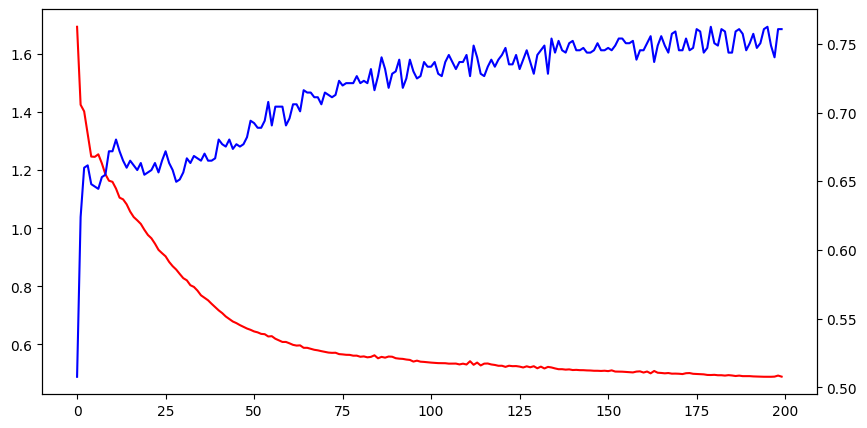

In [27]:
# 학습과정 표시(학습데이터에 대한 loss와 accuracy)
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'],'r')
acc_ax = loss_ax.twinx() #loss_ax와 x축을 공유하는 acc_ax
acc_ax.plot(hist.history.get('binary_accuracy'),'b')

In [28]:
# 모델 평가(X)
model.evaluate(X_train,y_train)

21/21 [==============================] - 0s 2ms/step - loss: 0.4982 - binary_accuracy: 0.7415


[0.49824580550193787, 0.7415384650230408]

In [29]:
#모델 평가(O)
model.evaluate(X_test, y_test)

4/4 [==============================] - 0s 2ms/step - loss: 0.6647 - binary_accuracy: 0.6441


[0.6646916270256042, 0.6440678238868713]

## 혼동행렬
- 테스트 데이터셋의 실제값과 예측값으로 작성된 교차표

In [34]:
y_test[:5]

array([0., 0., 0., 0., 0.])

In [37]:
# 실제값 : y_test (118개)
# 예측값
y_hat = (model.predict(X_test)>=0.5).astype(float)

4/4 [==============================] - 0s 2ms/step


In [42]:
TN = 0 #0을 0으로 예측한 경우의 수(T)
FP = 0 #0을 1로 예측한 경우의 수(F)
FN = 0 #1을 0으로 예측한 경우의 수(F)
TP = 0 #1을 1로 예측한 경우의 수(T)
print(y_test.shape, y_hat.shape)
for y, h in zip(y_test, y_hat.reshape(-1)):
    if y == 0 and h==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, FP)
print(FN, TP)

(118,) (118, 1)
60 13
29 16


In [46]:
#교차표
ctab = pd.crosstab(y_test, #실제값
                  y_hat.reshape(-1)) #예측값
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
ctab
pd.crosstab(y_test, #실제값
                  y_hat.reshape(-1),#예측값
                  rownames=['실제값'],
                  colnames=['예측값']) 

예측값,0.0,1.0
실제값,,
0.0,60,13
1.0,29,16


In [47]:
#혼동행렬
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,
                y_hat.reshape(-1))

array([[60, 13],
       [29, 16]], dtype=int64)

In [52]:
#accuracy
print('accuracy:',(TN+TP)/(TN+TP+FN+FP))
print('recall:',TP/(TP+FN))
print('precision:',TP/(FP+TP))

accuracy: 0.6440677966101694
recall: 0.35555555555555557
precision: 0.5517241379310345


# 6. 모델 사용

In [53]:
X_test[0]

array([  1.   ,  91.   ,  54.   ,  25.   , 100.   ,  25.2  ,   0.234,
        23.   ])

In [56]:
(model.predict(np.array([[1.,  91.,  54.,  25., 100.,25.,0.234,23.],
                        [0,  91.,  54.,  25., 100.,25.,0.234,23.]]))>=0.5).astype(int)

1/1 [==============================] - 0s 21ms/step


array([[0],
       [0]])

# 분류분석
1. 데이터셋 생성 및 전처리 : 순련셋(600), 검증셋(100), 테스트셋(68)
2. 모델 생성(input8, output2): 출력층 softmax(출력합을 1)
     * model.summary() 파라미터 수와 메모리 확인
3. 모델 학습과정 설정 : loss="categorical_crossentropy, metrics=['accuracy']
4. 모델 학습 : 훈련셋과 검증셋
5. 모델 평가 : 그래프(hist.history), 평가(테스트셋), 교차표(테스트셋)
6. 모델 저장 및 사용 : predict결과에 argmax()
[99.2, 0.8]

## 1. 데이터 셋 생성 및 전처리

In [59]:
dataset = np.loadtxt('data/pima-indians-diabetes.csv', encoding='utf-8', delimiter=',')
dataset.shape

(768, 9)

In [60]:
#훈련셋(600), 검증셋(100), 테스트셋(68)
X_train = dataset[:600, :-1]
y_train = dataset[:600, -1]
X_val = dataset[600:700, :-1]
y_val = dataset[600:700, -1]
X_test = dataset[700:, :-1]
y_test = dataset[700:, -1]
X_train.shape, y_train.shape

((600, 8), (600,))

In [62]:
#타겟변수의 원핫인코딩(분류분석)
print(y_train[:5])
print(utils.to_categorical(y_train[:5]))
Y_train = utils.to_categorical(y_train)
Y_val = utils.to_categorical(y_val)
Y_test = utils.to_categorical(y_test)
y_train.shape, Y_train.shape, Y_val.shape, Y_test.shape

[1. 0. 1. 0. 1.]
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


((600,), (600, 2), (100, 2), (68, 2))

## 2. 모델 생성(input8, target2)
- 과적합 줄이는 단계 추가(dropout추가)

In [81]:
from tensorflow.keras.layers import Dropout
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2)) #과적합을 해결
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=2, activation='softmax'))
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 32)                288       
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_25 (Dense)            (None, 64)                2112      
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_26 (Dense)            (None, 16)                1040      
                                                                 
 dropout_5 (Dropout)         (None, 16)                0         
                                                                 
 dense_27 (Dense)            (None, 8)                

## 3. 학습과정 설정

In [82]:
model.compile(loss='categorical_crossentropy',
             optimizer='nadam',
             metrics=['accuracy'])

## 4. 모델 학습

In [83]:
hist = model.fit(X_train, Y_train,
                epochs=300,
                validation_data=(X_val, Y_val),
                verbose=1)

Epoch 1/300
19/19 [==============================] - 1s 12ms/step - loss: 12.4740 - accuracy: 0.4033 - val_loss: 2.2886 - val_accuracy: 0.4500
Epoch 2/300
19/19 [==============================] - 0s 4ms/step - loss: 4.1207 - accuracy: 0.5367 - val_loss: 0.9328 - val_accuracy: 0.5500
Epoch 3/300
19/19 [==============================] - 0s 4ms/step - loss: 1.9771 - accuracy: 0.5667 - val_loss: 0.7055 - val_accuracy: 0.6700
Epoch 4/300
19/19 [==============================] - 0s 4ms/step - loss: 1.6672 - accuracy: 0.5933 - val_loss: 0.6781 - val_accuracy: 0.6700
Epoch 5/300
19/19 [==============================] - 0s 4ms/step - loss: 1.3866 - accuracy: 0.5867 - val_loss: 0.6756 - val_accuracy: 0.6700
Epoch 6/300
19/19 [==============================] - 0s 4ms/step - loss: 1.1699 - accuracy: 0.6067 - val_loss: 0.6834 - val_accuracy: 0.6700
Epoch 7/300
19/19 [==============================] - 0s 4ms/step - loss: 1.0891 - accuracy: 0.6250 - val_loss: 0.6803 - val_accuracy: 0.6700
Epoch 8/300

Epoch 59/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6315 - accuracy: 0.6683 - val_loss: 0.6119 - val_accuracy: 0.6800
Epoch 60/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6398 - accuracy: 0.6700 - val_loss: 0.6120 - val_accuracy: 0.6800
Epoch 61/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6329 - accuracy: 0.6750 - val_loss: 0.6095 - val_accuracy: 0.6800
Epoch 62/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6206 - accuracy: 0.6750 - val_loss: 0.6103 - val_accuracy: 0.6700
Epoch 63/300
19/19 [==============================] - 0s 3ms/step - loss: 0.6387 - accuracy: 0.6533 - val_loss: 0.6084 - val_accuracy: 0.6800
Epoch 64/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6275 - accuracy: 0.6700 - val_loss: 0.6091 - val_accuracy: 0.6700
Epoch 65/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6280 - accuracy: 0.6650 - val_loss: 0.6062 - val_accuracy: 0.6800
Epoch 

19/19 [==============================] - 0s 4ms/step - loss: 0.6032 - accuracy: 0.6800 - val_loss: 0.5820 - val_accuracy: 0.7100
Epoch 117/300
19/19 [==============================] - 0s 3ms/step - loss: 0.6100 - accuracy: 0.6833 - val_loss: 0.5781 - val_accuracy: 0.7300
Epoch 118/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6072 - accuracy: 0.6850 - val_loss: 0.5790 - val_accuracy: 0.7200
Epoch 119/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6120 - accuracy: 0.6850 - val_loss: 0.5796 - val_accuracy: 0.7300
Epoch 120/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6000 - accuracy: 0.6800 - val_loss: 0.5800 - val_accuracy: 0.7200
Epoch 121/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5975 - accuracy: 0.6933 - val_loss: 0.5796 - val_accuracy: 0.7300
Epoch 122/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6060 - accuracy: 0.7017 - val_loss: 0.5815 - val_accuracy: 0.7200
Epoch 123/300

19/19 [==============================] - 0s 4ms/step - loss: 0.5984 - accuracy: 0.6917 - val_loss: 0.5816 - val_accuracy: 0.7200
Epoch 174/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5816 - accuracy: 0.7167 - val_loss: 0.5837 - val_accuracy: 0.7200
Epoch 175/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5749 - accuracy: 0.7183 - val_loss: 0.5769 - val_accuracy: 0.7300
Epoch 176/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5756 - accuracy: 0.7217 - val_loss: 0.5800 - val_accuracy: 0.7300
Epoch 177/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5735 - accuracy: 0.7033 - val_loss: 0.5823 - val_accuracy: 0.7200
Epoch 178/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5849 - accuracy: 0.6950 - val_loss: 0.5759 - val_accuracy: 0.7200
Epoch 179/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5829 - accuracy: 0.7083 - val_loss: 0.5717 - val_accuracy: 0.7200
Epoch 180/300

19/19 [==============================] - 0s 4ms/step - loss: 0.5736 - accuracy: 0.7117 - val_loss: 0.5632 - val_accuracy: 0.7100
Epoch 231/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5486 - accuracy: 0.7383 - val_loss: 0.5655 - val_accuracy: 0.7000
Epoch 232/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5485 - accuracy: 0.7267 - val_loss: 0.5728 - val_accuracy: 0.6900
Epoch 233/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5636 - accuracy: 0.7167 - val_loss: 0.5602 - val_accuracy: 0.7400
Epoch 234/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5578 - accuracy: 0.7250 - val_loss: 0.5655 - val_accuracy: 0.7100
Epoch 235/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5704 - accuracy: 0.7083 - val_loss: 0.5680 - val_accuracy: 0.7100
Epoch 236/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5525 - accuracy: 0.7217 - val_loss: 0.5791 - val_accuracy: 0.7000
Epoch 237/300

19/19 [==============================] - 0s 4ms/step - loss: 0.5460 - accuracy: 0.7450 - val_loss: 0.5518 - val_accuracy: 0.7200
Epoch 288/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5237 - accuracy: 0.7300 - val_loss: 0.5571 - val_accuracy: 0.7000
Epoch 289/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5177 - accuracy: 0.7583 - val_loss: 0.5417 - val_accuracy: 0.7300
Epoch 290/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5455 - accuracy: 0.7283 - val_loss: 0.5598 - val_accuracy: 0.7000
Epoch 291/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5340 - accuracy: 0.7433 - val_loss: 0.5545 - val_accuracy: 0.7200
Epoch 292/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5280 - accuracy: 0.7167 - val_loss: 0.5309 - val_accuracy: 0.7400
Epoch 293/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5473 - accuracy: 0.7150 - val_loss: 0.5550 - val_accuracy: 0.6900
Epoch 294/300

## 5. 학습과정 살펴보기

In [84]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

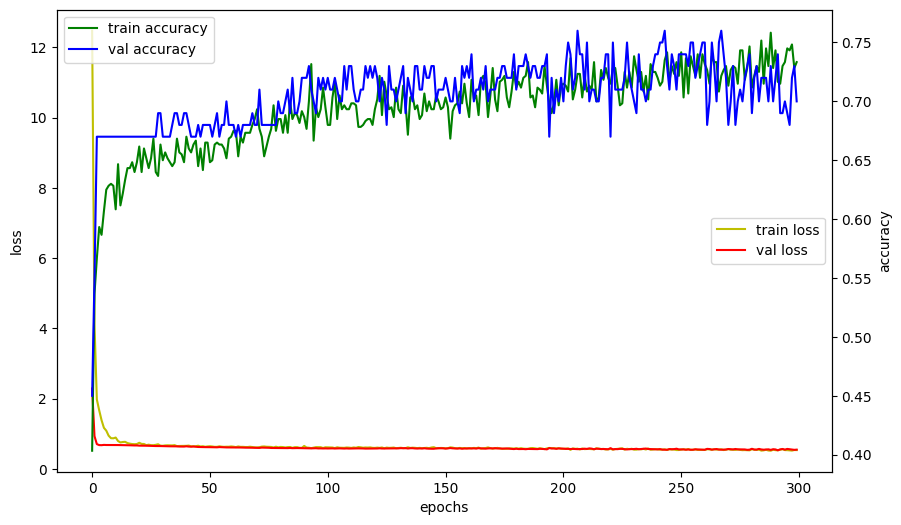

In [87]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

## 6. 모델 평가 & 교차표

In [88]:
model.evaluate(X_test, Y_test)

3/3 [==============================] - 0s 2ms/step - loss: 0.6449 - accuracy: 0.6324


[0.6448836326599121, 0.6323529481887817]

In [89]:
y_hat = model.predict(X_test).argmax(axis=1)
y_hat

3/3 [==============================] - 0s 2ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0], dtype=int64)

In [90]:
pd.crosstab(y_test, y_hat)

col_0,0,1
row_0,,
0.0,41,0
1.0,25,2


In [91]:
confusion_matrix(y_test, y_hat)

array([[41,  0],
       [25,  2]], dtype=int64)

## 7. 모델 저장 및 사용

In [92]:
from tensorflow.keras.models import save_model, load_model
#model.save('model/06_pima.h5')
save_model(model, 'model/06_pima.h5')

In [93]:
model2 = load_model('model/06_pima.h5')

In [98]:
pred = model2.predict([[2,122,76,27, 200,35.9,0.483,26],
               [6, 125,78,31,0,27.6,0.565,49]])
pred.argmax(axis=1)

1/1 [==============================] - 0s 38ms/step


array([0, 0], dtype=int64)

In [99]:
np.argmax(pred, axis=1)

array([0, 0], dtype=int64)